 # <div style="text-align: center; color: purple ;"> Cosmic Distance Ladder </div>

### <div style="text-align: left ; color: Magenta ;"> Task 1 </div>

### <div style="text-align: left ; color: black ;"> Use parallax for nearby stars (GAIA data) </div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
gaia = pd.read_csv(r"C:\Users\hp\Downloads\Python Project\gaia_data.csv.csv")

gaia

# parallax in milliarcseconds 

,source_id,ra,dec,parallax,parallax_error,phot_g_mean_mag
0,3371550165888,45.033605,0.128549,1.740795,0.088488,14.561540
1,3917010338944,45.083680,0.169355,1.017878,0.101519,17.389402
2,4020090844672,45.126605,0.182919,1.406082,1.159331,20.642280
3,4814659150336,44.912779,0.124004,1.431883,0.094242,17.152240
4,6631429670400,45.013587,0.170514,3.595164,0.039680,15.907244
...,...,...,...,...,...,...
595,1284096437919744,44.474488,2.204062,1.345010,0.165498,18.166874
596,1285019855697792,44.188030,2.020340,2.355263,0.755430,20.333569
597,1288528844124288,44.224481,2.145650,1.696911,0.343913,19.307348
598,1290448694119680,44.069439,2.121290,1.240918,0.408561,19.591843


In [3]:
gaia["d_pc"] = 1 / (gaia["parallax"] / 1000)

gaia

,source_id,ra,dec,parallax,parallax_error,phot_g_mean_mag,d_pc
0,3371550165888,45.033605,0.128549,1.740795,0.088488,14.561540,574.450040
1,3917010338944,45.083680,0.169355,1.017878,0.101519,17.389402,982.435769
2,4020090844672,45.126605,0.182919,1.406082,1.159331,20.642280,711.195899
3,4814659150336,44.912779,0.124004,1.431883,0.094242,17.152240,698.381245
4,6631429670400,45.013587,0.170514,3.595164,0.039680,15.907244,278.151407
...,...,...,...,...,...,...,...
595,1284096437919744,44.474488,2.204062,1.345010,0.165498,18.166874,743.488879
596,1285019855697792,44.188030,2.020340,2.355263,0.755430,20.333569,424.581095
597,1288528844124288,44.224481,2.145650,1.696911,0.343913,19.307348,589.306020
598,1290448694119680,44.069439,2.121290,1.240918,0.408561,19.591843,805.855170


In [4]:
gaia_cepheid1 = pd.read_csv(r"C:\Users\hp\Downloads\Python Project\gaia_data_cepheid.csv.csv")

In [5]:
gaia_cepheid1

,source_id,ra,dec,parallax,parallax_error,parallax_corrected,period_days,mean_g_mag,mean_bp_mag,mean_rp_mag,g_mag_error,bp_mag_error,rp_mag_error
0,4156450099578283776,279.513773,-8.368947,0.518477,0.020342,0.548477,10.341813,8.866850,9.823165,7.873170,0.034152,0.029981,0.082491
1,5862711040048310528,193.613104,-63.935304,0.308704,0.019459,0.338704,24.062340,11.200543,12.987680,9.952066,0.003423,0.052031,0.019013
2,5332397512328481920,177.735016,-65.140712,0.252034,0.017163,0.282034,4.944982,11.146012,11.976557,10.242218,0.003224,0.004467,0.018857
3,207722317998325632,80.889831,44.760076,0.215124,0.015191,0.245124,2.476962,12.738015,13.435085,11.918398,0.003535,0.007295,0.002509
4,5614312705966204288,117.016035,-25.577771,0.233082,0.016544,0.263082,13.597380,9.540547,10.125006,8.785503,0.002671,0.014504,0.007556
...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,5254070090673438592,160.595908,-61.165901,0.403928,0.011091,0.433928,2.875924,10.035659,10.551370,9.334990,0.008338,0.020243,0.009164
477,5339394082770287232,167.421345,-58.837715,0.858683,0.014970,0.888683,7.719662,6.614056,7.035534,6.012368,0.002698,0.002279,0.007681
478,468431815031779456,60.378875,55.045332,0.248443,0.017679,0.278443,6.602993,11.929178,13.097909,10.862187,0.001497,0.004971,0.000852
479,4285878256152184832,282.645305,7.125981,0.318086,0.026304,0.348086,18.992527,10.906177,12.703903,9.657742,0.013916,0.013502,0.022976


In [6]:
gaia_cepheid2 =gaia_cepheid1[
    (gaia_cepheid1['parallax_corrected'] > 0) & 
    (gaia_cepheid1['parallax_error'] / gaia_cepheid1['parallax_corrected'] < 0.05)  # 10% uncertainty or better
].copy()
gaia_cepheid2

,source_id,ra,dec,parallax,parallax_error,parallax_corrected,period_days,mean_g_mag,mean_bp_mag,mean_rp_mag,g_mag_error,bp_mag_error,rp_mag_error
0,4156450099578283776,279.513773,-8.368947,0.518477,0.020342,0.548477,10.341813,8.866850,9.823165,7.873170,0.034152,0.029981,0.082491
6,5835124087174043136,244.715952,-57.899803,1.077423,0.021940,1.107423,9.754416,6.165421,6.654251,5.491594,0.004268,0.005683,0.003508
7,430670222050230912,9.185444,62.274237,0.231169,0.012749,0.261169,6.239973,11.720706,12.697921,10.740953,0.001265,0.001360,0.001071
8,2067549118302850304,306.080585,40.561064,0.330698,0.017684,0.360698,20.053370,10.386857,12.121343,9.158795,0.068023,0.086176,0.030571
9,5258574068224211200,153.886892,-58.174438,0.326984,0.014117,0.356984,4.932464,10.250946,10.914950,9.452414,0.001333,0.002996,0.000536
...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,5852389305960163328,208.755409,-64.031948,0.309790,0.015420,0.339790,4.169429,11.278795,12.159182,10.345758,0.000941,0.000845,0.006264
473,1977074811892425600,332.262062,51.045845,0.408511,0.012897,0.438511,4.323754,8.977802,9.388089,8.377266,0.002016,0.001169,0.000468
476,5254070090673438592,160.595908,-61.165901,0.403928,0.011091,0.433928,2.875924,10.035659,10.551370,9.334990,0.008338,0.020243,0.009164
477,5339394082770287232,167.421345,-58.837715,0.858683,0.014970,0.888683,7.719662,6.614056,7.035534,6.012368,0.002698,0.002279,0.007681


In [7]:
gaia_cepheid2['distance_pc'] = 1000.0 / gaia_cepheid2['parallax_corrected']
gaia_cepheid2['true_absolute_mag'] = (
   gaia_cepheid2['mean_rp_mag'] - 
    (5 * np.log10(gaia_cepheid2['distance_pc']) - 5)
)
gaia_cepheid2


,source_id,ra,dec,parallax,parallax_error,parallax_corrected,period_days,mean_g_mag,mean_bp_mag,mean_rp_mag,g_mag_error,bp_mag_error,rp_mag_error,distance_pc,true_absolute_mag
0,4156450099578283776,279.513773,-8.368947,0.518477,0.020342,0.548477,10.341813,8.866850,9.823165,7.873170,0.034152,0.029981,0.082491,1823.231876,-3.431039
6,5835124087174043136,244.715952,-57.899803,1.077423,0.021940,1.107423,9.754416,6.165421,6.654251,5.491594,0.004268,0.005683,0.003508,902.997515,-4.286839
7,430670222050230912,9.185444,62.274237,0.231169,0.012749,0.261169,6.239973,11.720706,12.697921,10.740953,0.001265,0.001360,0.001071,3828.931366,-2.174435
8,2067549118302850304,306.080585,40.561064,0.330698,0.017684,0.360698,20.053370,10.386857,12.121343,9.158795,0.068023,0.086176,0.030571,2772.403007,-3.055487
9,5258574068224211200,153.886892,-58.174438,0.326984,0.014117,0.356984,4.932464,10.250946,10.914950,9.452414,0.001333,0.002996,0.000536,2801.242519,-2.784340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,5852389305960163328,208.755409,-64.031948,0.309790,0.015420,0.339790,4.169429,11.278795,12.159182,10.345758,0.000941,0.000845,0.006264,2942.997111,-1.998191
473,1977074811892425600,332.262062,51.045845,0.408511,0.012897,0.438511,4.323754,8.977802,9.388089,8.377266,0.002016,0.001169,0.000468,2280.447097,-3.412834
476,5254070090673438592,160.595908,-61.165901,0.403928,0.011091,0.433928,2.875924,10.035659,10.551370,9.334990,0.008338,0.020243,0.009164,2304.529912,-2.477922
477,5339394082770287232,167.421345,-58.837715,0.858683,0.014970,0.888683,7.719662,6.614056,7.035534,6.012368,0.002698,0.002279,0.007681,1125.260721,-4.243898


In [8]:
gaia_cepheid = gaia_cepheid2[
    (gaia_cepheid2['true_absolute_mag'] < -2) &           # Cepheids are bright: M < -2
    (gaia_cepheid2['period_days'] >= 2) &      # Avoid very short periods
    (gaia_cepheid2['period_days'] <= 100) & 
    (gaia_cepheid2['true_absolute_mag'] > -6)   # Not TOO bright
].copy()


In [9]:
gaia_cepheid

,source_id,ra,dec,parallax,parallax_error,parallax_corrected,period_days,mean_g_mag,mean_bp_mag,mean_rp_mag,g_mag_error,bp_mag_error,rp_mag_error,distance_pc,true_absolute_mag
0,4156450099578283776,279.513773,-8.368947,0.518477,0.020342,0.548477,10.341813,8.866850,9.823165,7.873170,0.034152,0.029981,0.082491,1823.231876,-3.431039
6,5835124087174043136,244.715952,-57.899803,1.077423,0.021940,1.107423,9.754416,6.165421,6.654251,5.491594,0.004268,0.005683,0.003508,902.997515,-4.286839
7,430670222050230912,9.185444,62.274237,0.231169,0.012749,0.261169,6.239973,11.720706,12.697921,10.740953,0.001265,0.001360,0.001071,3828.931366,-2.174435
8,2067549118302850304,306.080585,40.561064,0.330698,0.017684,0.360698,20.053370,10.386857,12.121343,9.158795,0.068023,0.086176,0.030571,2772.403007,-3.055487
9,5258574068224211200,153.886892,-58.174438,0.326984,0.014117,0.356984,4.932464,10.250946,10.914950,9.452414,0.001333,0.002996,0.000536,2801.242519,-2.784340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,5935042378098601856,243.981435,-51.120729,0.308712,0.015328,0.338712,6.812698,10.324901,11.289794,9.364626,0.000641,0.003449,0.002956,2952.364637,-2.986224
473,1977074811892425600,332.262062,51.045845,0.408511,0.012897,0.438511,4.323754,8.977802,9.388089,8.377266,0.002016,0.001169,0.000468,2280.447097,-3.412834
476,5254070090673438592,160.595908,-61.165901,0.403928,0.011091,0.433928,2.875924,10.035659,10.551370,9.334990,0.008338,0.020243,0.009164,2304.529912,-2.477922
477,5339394082770287232,167.421345,-58.837715,0.858683,0.014970,0.888683,7.719662,6.614056,7.035534,6.012368,0.002698,0.002279,0.007681,1125.260721,-4.243898


### <div style="text-align: left ; color: Magenta ;"> Task 2 </div>

### <div style="text-align: left ; color:black ;"> Apply period-luminosity relation for Cepheid variables</div>

### <div style="text-align: left ; color: blue ;"> Option 1 </div>

In [10]:
cepheid = pd.read_csv(r"C:\Users\hp\Downloads\Python Project\cepheid.dat.txt")

In [11]:
cepheid.head()

,# Date: 2026-04-23 18:04:40
0,# Database: ocvs
1,# Target: lmc_cepheids
2,# Query: (mode='F') LIMIT 600
3,# Objects: 600
4,# Columns:


In [12]:
cepheid

,# Date: 2026-04-23 18:04:40
0,# Database: ocvs
1,# Target: lmc_cepheids
2,# Query: (mode='F') LIMIT 600
3,# Objects: 600
4,# Columns:
...,...
601,OGLE-LMC-CEP-1057\tF\t05:08:17.66\t-70:11:28.6...
602,OGLE-LMC-CEP-1058\tF\t05:08:18.26\t-68:46:47.1...
603,OGLE-LMC-CEP-1061\tF\t05:08:20.13\t-70:43:44.9...
604,OGLE-LMC-CEP-1070\tF\t05:08:30.37\t-69:07:42.5...


In [13]:
# See all column names
print(cepheid.columns.tolist())

# Look at the first few rows to understand the structure
print(cepheid.head())


['# Date:     2026-04-23 18:04:40']
     # Date:     2026-04-23 18:04:40
0                   # Database: ocvs
1           # Target:   lmc_cepheids
2  # Query:    (mode='F')  LIMIT 600
3                    # Objects:  600
4                         # Columns:


In [14]:
cepheid = pd.read_csv(
  r"C:\Users\hp\Downloads\Python Project\cepheid.dat.txt",  
    sep='\t',              
    comment='#',           # Skip lines that start with '#'
    header=0               # First non-comment line is column headers
)

print(cepheid.head())

                  ID Mode           RA         Decl       I       V    V_I  \
0  OGLE-LMC-CEP-0002    F  04:31:47.05  -69:49:09.5  15.691  16.420  0.729   
1  OGLE-LMC-CEP-0005    F  04:35:31.52  -69:44:05.8  14.651  15.425  0.774   
2  OGLE-LMC-CEP-0012    F  04:37:48.74  -67:12:51.9  15.474  16.075  0.601   
3  OGLE-LMC-CEP-0017    F  04:38:56.83  -69:41:18.3  15.237  15.899  0.662   
4  OGLE-LMC-CEP-0018    F  04:38:58.98  -68:57:24.8  15.181  15.994  0.813   

        P_1      dP_1        T0_1    A_1  
0  3.118149  0.000011  6000.34799  0.261  
1  5.611949  0.000013  6004.75854  0.508  
2  2.660184  0.000002  6001.07578  0.691  
3  3.677290  0.000006  6001.21645  0.594  
4  4.047837  0.000018  6002.75795  0.247  


In [15]:
# df = cepheid [["P_1", "I","V"]].dropna()
# df = cepheid [df["P_1"] > 0]
# df = cepheid [df["V"] > 0]
# df = cepheid [df["I"] > 0] 
# To delete the values like -99.99
# Method 2: Step-by-step filtering (properly)
df = cepheid[["P_1", "I", "V"]].dropna()
df = df[df["P_1"] > 0]
df = df[df["V"] > 0]
df = df[df["I"] > 0]

In [16]:
df

,P_1,I,V
0,3.118149,15.691,16.420
1,5.611949,14.651,15.425
2,2.660184,15.474,16.075
3,3.677290,15.237,15.899
4,4.047837,15.181,15.994
...,...,...,...
594,4.460666,14.959,15.769
595,5.074015,14.734,15.490
597,2.598053,15.707,16.415
598,2.788692,15.536,16.224


In [17]:
# df["logP"] = np.log10(df["P_1"])
df = df.copy()
df.loc[:, "logP"] = np.log10(df["P_1"])

In [18]:
df

,P_1,I,V,logP
0,3.118149,15.691,16.420,0.493897
1,5.611949,14.651,15.425,0.749114
2,2.660184,15.474,16.075,0.424912
3,3.677290,15.237,15.899,0.565528
4,4.047837,15.181,15.994,0.607223
...,...,...,...,...
594,4.460666,14.959,15.769,0.649400
595,5.074015,14.734,15.490,0.705352
597,2.598053,15.707,16.415,0.414648
598,2.788692,15.536,16.224,0.445401


In [19]:
df["Mv"] = -(2.76 * (df["logP"]- 1.0)) - 4.16

In [20]:
df

,P_1,I,V,logP,Mv
0,3.118149,15.691,16.420,0.493897,-2.763155
1,5.611949,14.651,15.425,0.749114,-3.467554
2,2.660184,15.474,16.075,0.424912,-2.572756
3,3.677290,15.237,15.899,0.565528,-2.960857
4,4.047837,15.181,15.994,0.607223,-3.075935
...,...,...,...,...,...
594,4.460666,14.959,15.769,0.649400,-3.192343
595,5.074015,14.734,15.490,0.705352,-3.346771
597,2.598053,15.707,16.415,0.414648,-2.544429
598,2.788692,15.536,16.224,0.445401,-2.629305


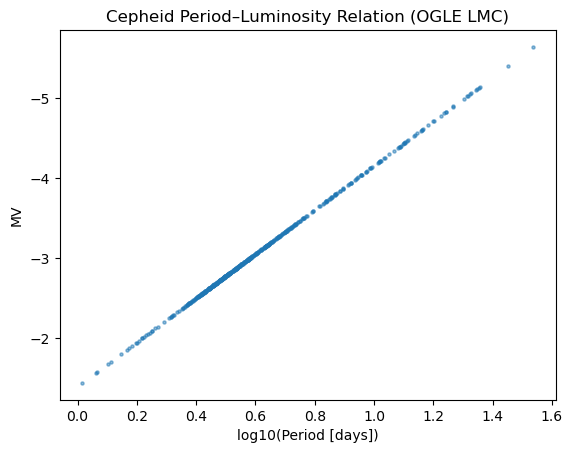

In [21]:
plt.figure()
plt.scatter(df["logP"], df["Mv"], s=5, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel("log10(Period [days])")
plt.ylabel("MV")
plt.title("Cepheid Period–Luminosity Relation (OGLE LMC)")
plt.show()

In [22]:
df['d_pc_dir'] = 10 ** ((df["V"] - df["Mv"] + 5) / 5)
df["d_Kpc_dir"]=df['d_pc_dir']/1e3

In [23]:
df['d_pc_dir'].mean()

np.float64(61749.32284108925)

In [24]:
df

,P_1,I,V,logP,Mv,d_pc_dir,d_Kpc_dir
0,3.118149,15.691,16.420,0.493897,-2.763155,68648.502653,68.648503
1,5.611949,14.651,15.425,0.749114,-3.467554,60049.690767,60.049691
2,2.660184,15.474,16.075,0.424912,-2.572756,53647.715960,53.647716
3,3.677290,15.237,15.899,0.565528,-2.960857,59152.270092,59.152270
4,4.047837,15.181,15.994,0.607223,-3.075935,65160.903703,65.160904
...,...,...,...,...,...,...,...
594,4.460666,14.959,15.769,0.649400,-3.192343,61982.434041,61.982434
595,5.074015,14.734,15.490,0.705352,-3.346771,58526.719648,58.526720
597,2.598053,15.707,16.415,0.414648,-2.544429,61927.810743,61.927811
598,2.788692,15.536,16.224,0.445401,-2.629305,58974.066919,58.974067


## Option 2


In [25]:
gaia_cepheid1 = pd.read_csv(r"C:\Users\hp\Downloads\Python Project\gaia_data_cepheid.csv.csv")

# Fit the Period-Luminosity relation: M = a * log10(P) + b

In [26]:
M_true = gaia_cepheid['true_absolute_mag'] 
gaia_cepheid.loc[:, "logP_gaia"] = np.log10(gaia_cepheid["period_days"])

In [27]:
from scipy.stats import linregress

a, b, r_value, p_value, std_err = linregress(gaia_cepheid["logP_gaia"], M_true) # a=slope , b=intercept

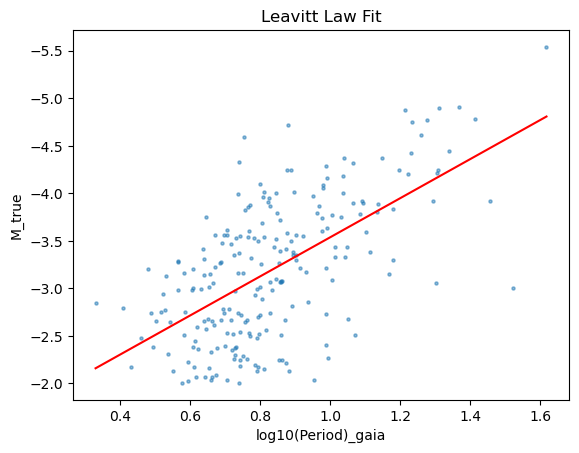

In [28]:
x = np.linspace(gaia_cepheid["logP_gaia"].min(), gaia_cepheid["logP_gaia"].max(), 100)
y = a * x + b

plt.figure()
plt.scatter(gaia_cepheid["logP_gaia"], M_true, s=5, alpha=0.5)
plt.plot(x, y, color="red")
plt.gca().invert_yaxis()
plt.xlabel("log10(Period)_gaia")
plt.ylabel("M_true")
plt.title("Leavitt Law Fit")
plt.show()

In [29]:
print(a, b, r_value, p_value, std_err,sep='\n')

-2.0552591635943163
-1.481115315530695
-0.6125171010188737
1.8492567792994824e-24
0.17801242739505108


In [30]:
def calibrated_absolute_magnitude(period_days):
    return a * np.log10(period_days) + b

In [31]:
gaia_cepheid['M_calibrated'] = gaia_cepheid['period_days'].apply(calibrated_absolute_magnitude)
gaia_cepheid['distance_pc_calibrated'] = 10 ** ((gaia_cepheid['mean_rp_mag'] - gaia_cepheid['M_calibrated'] + 5) / 5)

In [32]:
gaia_cepheid['distance_pc_calibrated'].mean()

np.float64(2354.148690563924)

In [33]:
gaia_cepheid

,source_id,ra,dec,parallax,parallax_error,parallax_corrected,period_days,mean_g_mag,mean_bp_mag,mean_rp_mag,g_mag_error,bp_mag_error,rp_mag_error,distance_pc,true_absolute_mag,logP_gaia,M_calibrated,distance_pc_calibrated
0,4156450099578283776,279.513773,-8.368947,0.518477,0.020342,0.548477,10.341813,8.866850,9.823165,7.873170,0.034152,0.029981,0.082491,1823.231876,-3.431039,1.014597,-3.566374,1940.479069
6,5835124087174043136,244.715952,-57.899803,1.077423,0.021940,1.107423,9.754416,6.165421,6.654251,5.491594,0.004268,0.005683,0.003508,902.997515,-4.286839,0.989201,-3.514180,632.637405
7,430670222050230912,9.185444,62.274237,0.231169,0.012749,0.261169,6.239973,11.720706,12.697921,10.740953,0.001265,0.001360,0.001071,3828.931366,-2.174435,0.795183,-3.115422,5905.748671
8,2067549118302850304,306.080585,40.561064,0.330698,0.017684,0.360698,20.053370,10.386857,12.121343,9.158795,0.068023,0.086176,0.030571,2772.403007,-3.055487,1.302187,-4.157448,4605.200778
9,5258574068224211200,153.886892,-58.174438,0.326984,0.014117,0.356984,4.932464,10.250946,10.914950,9.452414,0.001333,0.002996,0.000536,2801.242519,-2.784340,0.693064,-2.905541,2962.041028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,5935042378098601856,243.981435,-51.120729,0.308712,0.015328,0.338712,6.812698,10.324901,11.289794,9.364626,0.000641,0.003449,0.002956,2952.364637,-2.986224,0.833319,-3.193802,3248.520482
473,1977074811892425600,332.262062,51.045845,0.408511,0.012897,0.438511,4.323754,8.977802,9.388089,8.377266,0.002016,0.001169,0.000468,2280.447097,-3.412834,0.635861,-2.787974,1710.204717
476,5254070090673438592,160.595908,-61.165901,0.403928,0.011091,0.433928,2.875924,10.035659,10.551370,9.334990,0.008338,0.020243,0.009164,2304.529912,-2.477922,0.458777,-2.424022,2248.031435
477,5339394082770287232,167.421345,-58.837715,0.858683,0.014970,0.888683,7.719662,6.614056,7.035534,6.012368,0.002698,0.002279,0.007681,1125.260721,-4.243898,0.887598,-3.305360,730.374355


## Option 3


In [34]:
from scipy.stats import linregress

a, b, r_value, p_value, std_err = linregress(df["logP"], df["I"]) # a=slope , b=intercept

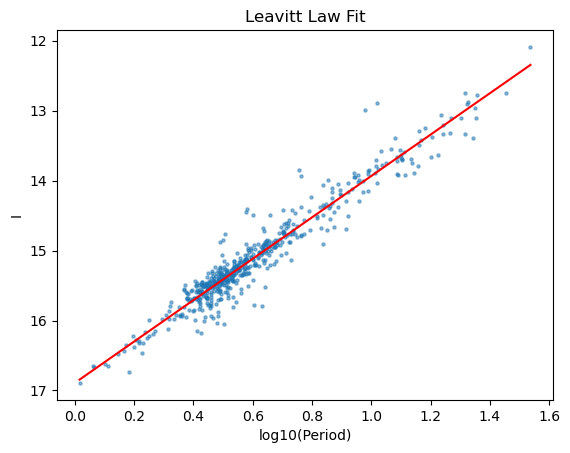

In [35]:
x = np.linspace(df["logP"].min(), df["logP"].max(), 100)
y = a * x + b

plt.figure()
plt.scatter(df["logP"], df["I"], s=5, alpha=0.5)
plt.plot(x, y, color="red")
plt.gca().invert_yaxis()
plt.xlabel("log10(Period)")
plt.ylabel("I")
plt.title("Leavitt Law Fit")
plt.show()

In [36]:
print(a, b, r_value, p_value, std_err,sep='\n')

-2.957851035281225
16.891459509791762
-0.9648016725716252
2.03257233e-315
0.034694588713651456


In [37]:
mu = 18.5
df.loc[:,"M_I"] = df["I"] - mu

In [38]:
from scipy.stats import linregress

a, b, r_value, p_value, std_err = linregress(df["logP"], df["M_I"])

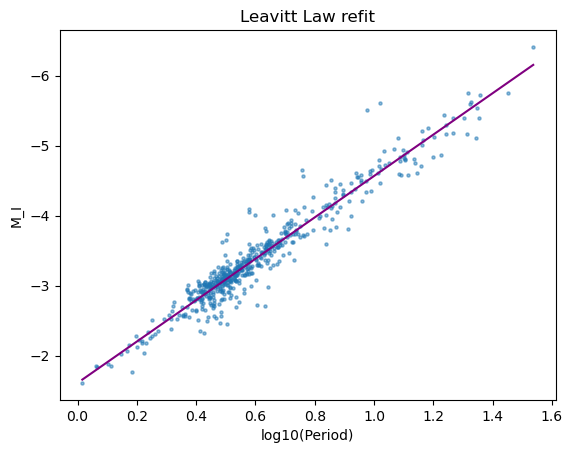

In [39]:
x = np.linspace(df["logP"].min(), df["logP"].max(), 100)
y = a * x + b

plt.figure()
plt.scatter(df["logP"], df["M_I"], s=5, alpha=0.5)
plt.plot(x, y, color="purple")
plt.gca().invert_yaxis()
plt.xlabel("log10(Period)")
plt.ylabel("M_I")
plt.title("Leavitt Law refit")
plt.show()

In [40]:
print(a, b, r_value, p_value, std_err,sep='\n')


-2.957851035281225
-1.6085404902082385
-0.9648016725716253
2.03257233e-315
0.03469458871365139


In [41]:

df["M_model"] = a * df["logP"] + b

In [42]:
df["mu"] = df["I"] - df["M_model"]

In [43]:
df["mu"]

0      18.760414
1      18.475307
2      18.339366
3      18.518288
4      18.585616
         ...    
594    18.488368
595    18.428866
597    18.542008
598    18.461969
599    18.562497
Name: mu, Length: 542, dtype: float64

In [44]:
df['d_pc'] = 10 ** ((df["mu"] + 5) / 5)
df['d_pc']

0      56504.465116
1      49552.030859
2      46545.015272
3      50542.599123
4      52134.250806
           ...     
594    49850.969057
595    48503.513275
597    51097.721473
598    49248.586079
599    51582.151796
Name: d_pc, Length: 542, dtype: float64

In [45]:
mu_mean = df["mu"].mean()
mu_std = df["mu"].std()

print("Distance modulus =", mu_mean)
print("Scatter =", mu_std)

Distance modulus = 18.5
Scatter = 0.1950781508981812


In [46]:
d_pc = 10 ** ((mu_mean + 5) / 5)

print("Distance to LMC (pc):", d_pc)
print("Distance to LMC (kpc):", d_pc / 1000)

Distance to LMC (pc): 50118.72336272725
Distance to LMC (kpc): 50.11872336272725


### <div style="text-align: left ; color: Magenta ;"> Task 3</div>

### <div style="text-align: left ; color: black ;"> Use Type Ia supernovae as standard candles</div>

In [47]:
df2 = pd.read_csv(r"C:\Users\hp\Downloads\Python Project\Pantheon+SH0ES.dat", sep=r"\s+")
df2
df_clean = df2[["zCMB", "MU_SH0ES", "MU_SH0ES_ERR_DIAG"]]

# remove invalid rows (-999 or NaN values)
df_clean = df_clean.replace(-999, pd.NA).dropna()

print(df_clean.head())
df_clean

      zCMB  MU_SH0ES  MU_SH0ES_ERR_DIAG
0  0.00122   28.9987           1.516450
1  0.00122   29.0559           1.517470
2  0.00256   30.7233           0.782372
3  0.00256   30.7449           0.799068
4  0.00299   30.7757           0.881212


,zCMB,MU_SH0ES,MU_SH0ES_ERR_DIAG
0,0.00122,28.9987,1.516450
1,0.00122,29.0559,1.517470
2,0.00256,30.7233,0.782372
3,0.00256,30.7449,0.799068
4,0.00299,30.7757,0.881212
...,...,...,...
1696,1.61499,45.1595,0.333024
1697,1.69702,45.2863,0.380480
1698,1.80111,45.4865,0.281981
1699,1.91160,45.4233,0.358642


In [48]:
df_sorted = df_clean.sort_values("zCMB")

In [49]:
df_sorted

,zCMB,MU_SH0ES,MU_SH0ES_ERR_DIAG
0,0.00122,28.9987,1.516450
1,0.00122,29.0559,1.517470
2,0.00256,30.7233,0.782372
3,0.00256,30.7449,0.799068
17,0.00293,31.4990,0.514259
...,...,...,...
1696,1.61499,45.1595,0.333024
1697,1.69702,45.2863,0.380480
1698,1.80111,45.4865,0.281981
1699,1.91160,45.4233,0.358642


In [50]:
df_sorted["d_pc"] = 10 ** (df_sorted["MU_SH0ES"] / 5 + 1)
df_sorted
df_sorted.mean()


zCMB                 2.210895e-01
MU_SH0ES             3.833663e+01
MU_SH0ES_ERR_DIAG    2.426009e-01
d_pc                 1.168643e+09
dtype: float64

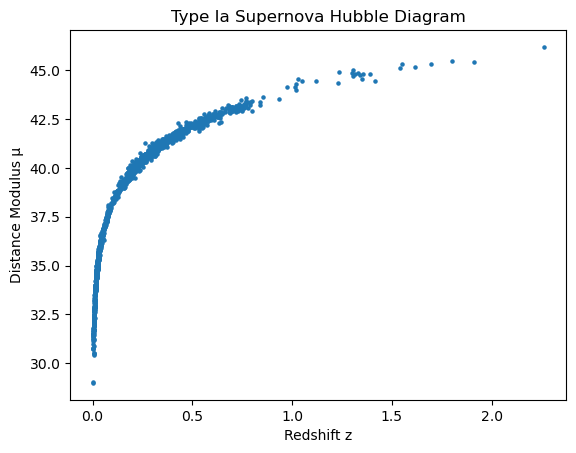

In [51]:
plt.scatter(df_clean["zCMB"],df_clean["MU_SH0ES"], s=5)
plt.xlabel("Redshift z")
plt.ylabel("Distance Modulus μ")
plt.title("Type Ia Supernova Hubble Diagram")
plt.show()

### <div style="text-align: left ; color: Magenta ;"> Task 4</div>

### <div style="text-align: left ; color: black;">  Calculate Hubble constant from galaxy redshifts</div>

### <div style="text-align: left ; color: purple ;"> for small z </div>

In [52]:
df_low = df_clean[df_clean["zCMB"] < 0.05]
df_low

,zCMB,MU_SH0ES,MU_SH0ES_ERR_DIAG
0,0.00122,28.9987,1.516450
1,0.00122,29.0559,1.517470
2,0.00256,30.7233,0.782372
3,0.00256,30.7449,0.799068
4,0.00299,30.7757,0.881212
...,...,...,...
645,0.04980,36.5693,0.155812
646,0.04998,36.8583,0.163226
647,0.04944,36.5403,0.453411
648,0.04970,36.4621,0.201896


In [53]:
df_sample = df_low.sample(640, random_state=42)
df_sample

,zCMB,MU_SH0ES,MU_SH0ES_ERR_DIAG
635,0.04780,36.5627,0.208806
220,0.01610,33.8410,0.289311
593,0.04015,36.0818,0.144980
429,0.02748,35.3613,0.190628
72,0.00769,32.6418,0.362719
...,...,...,...
87,0.00812,32.7223,0.383433
458,0.02886,35.0939,0.272694
330,0.02350,34.9850,0.190740
214,0.01633,34.3408,0.198023


In [54]:
c = 299792.458  # km/s
df_sample["v"] = c * df_sample["zCMB"]

In [55]:
df_sample["d_pc1"] = 10 ** (df_sample["MU_SH0ES"] / 5 + 1)
df_sample["d_Mpc"] = df_sample["d_pc1"] / 1e6

df_sample

,zCMB,MU_SH0ES,MU_SH0ES_ERR_DIAG,v,d_pc1,d_Mpc
635,0.04780,36.5627,0.208806,14330.079492,2.053714e+08,205.371417
220,0.01610,33.8410,0.289311,4826.658574,5.864082e+07,58.640815
593,0.04015,36.0818,0.144980,12036.667189,1.645735e+08,164.573536
429,0.02748,35.3613,0.190628,8238.296746,1.181027e+08,118.102747
72,0.00769,32.6418,0.362719,2305.404002,3.375670e+07,33.756701
...,...,...,...,...,...,...
87,0.00812,32.7223,0.383433,2434.314759,3.503160e+07,35.031602
458,0.02886,35.0939,0.272694,8652.010338,1.044191e+08,104.419113
330,0.02350,34.9850,0.190740,7045.122763,9.931160e+07,99.311605
214,0.01633,34.3408,0.198023,4895.610839,7.381761e+07,73.817613


In [56]:
from scipy.stats import linregress

x = df_sample["d_Mpc"]
y = df_sample["v"]

slope, intercept, r_value, p_value, std_err = linregress(x, y)

H0 = slope
print("Hubble constant H0 =", H0, "km/s/Mpc")

Hubble constant H0 = 67.62521257834442 km/s/Mpc


In [57]:
print(slope, intercept, r_value, p_value, std_err,sep='\n')

67.62521257834442
265.7317875135641
0.9863206400023578
0.0
0.44744303254398016


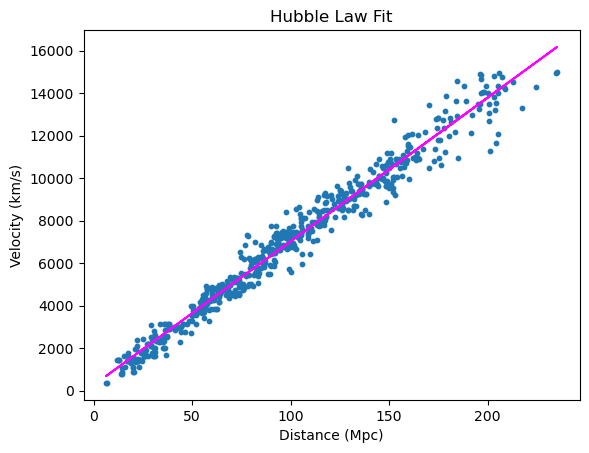

In [58]:
plt.scatter(x, y, s=10)

plt.plot(x, slope*x + intercept, color="Magenta")

plt.xlabel("Distance (Mpc)")
plt.ylabel("Velocity (km/s)")
plt.title("Hubble Law Fit")

plt.show()

### <div style="text-align: left ; color: Magenta ;"> Task 5</div>

### <div style="text-align: left ; color: black ;"> Compare and reconcile different distance measurements</div>

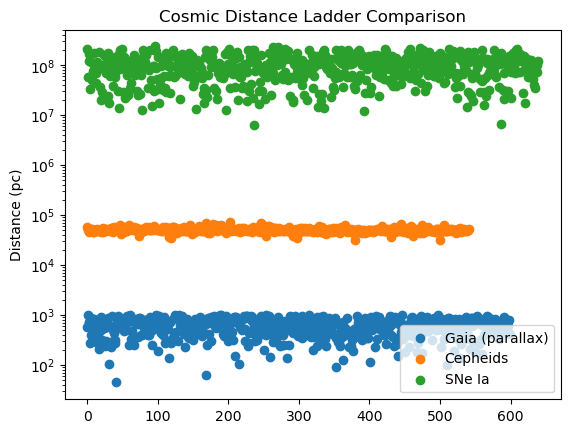

In [59]:
plt.figure()

plt.scatter(range(len(gaia["d_pc"])),gaia["d_pc"], label="Gaia (parallax)")
plt.scatter(range(len(df['d_pc'])), df['d_pc'], label="Cepheids")
plt.scatter(range(len(df_sample['d_pc1'])), df_sample['d_pc1'], label="SNe Ia")

plt.yscale("log")
plt.ylabel("Distance (pc)")
plt.title("Cosmic Distance Ladder Comparison")
plt.legend()
plt.show()

In [60]:
gaia_Mpc = gaia["d_pc"] / 1e6
cepheid_Mpc = df['d_pc'] / 1e6
SNe_Ia_Mpc=df_sample['d_pc1']/1e6

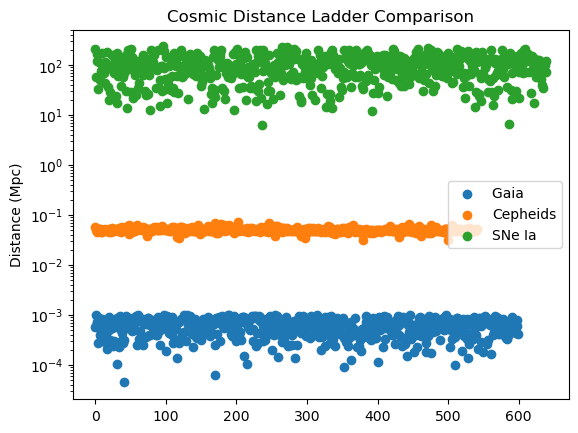

In [61]:
plt.figure()

plt.scatter(range(len(gaia_Mpc)), gaia_Mpc, label="Gaia ")
plt.scatter(range(len(cepheid_Mpc)), cepheid_Mpc, label="Cepheids")
plt.scatter(range(len(SNe_Ia_Mpc)), SNe_Ia_Mpc, label="SNe Ia")
plt.yscale("log")
plt.ylabel("Distance (Mpc)")
plt.title("Cosmic Distance Ladder Comparison")
plt.legend()
plt.show()

### <div style="text-align: left ; color: Magenta ;"> Task 6</div>

### <div style="text-align: left ; color: black ;"> Create a visualization of the cosmic distance ladder </div>

In [62]:
gaia_dist = gaia["d_pc"].mean()
cepheid_dist = df["d_pc"].mean()
sn_dist = df_sorted["d_pc"].mean()


In [63]:
print(gaia_dist/1e6,
   cepheid_dist/1e6,
   sn_dist/1e6)  

0.000587627274528172 0.050319128958088225 1168.6432902697074


In [64]:
methods = ["Parallax (Gaia)", "Cepheids (LMC)", "Type Ia SNe"]

# representative distances (in parsec)
distances_pc = np.array([
   gaia_dist,
   cepheid_dist,
   sn_dist      
])

In [65]:
log_d = np.log10(distances_pc)

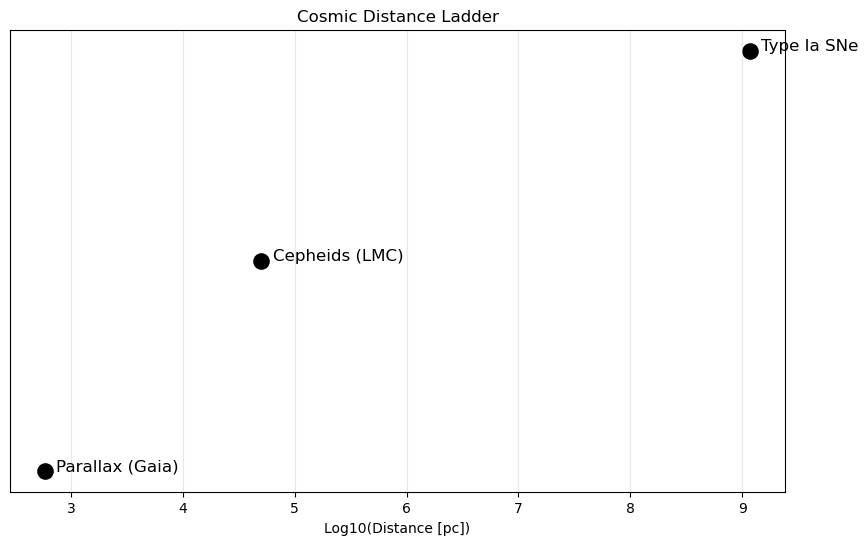

In [66]:
plt.figure(figsize=(10,6))

y_pos = np.arange(len(methods))

plt.scatter(log_d, y_pos, s=120, color="black")

for i in range(len(methods)):
    plt.text(log_d[i] + 0.1, y_pos[i], methods[i], fontsize=12)

plt.yticks([])
plt.xlabel("Log10(Distance [pc])")
plt.title("Cosmic Distance Ladder")

plt.grid(axis="x", alpha=0.3)

plt.show()